In [41]:
import pandas as pd
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from utils import *

In [ ]:
# Função que auxilia no salvamento de figuras
def salvar_plot(nome):
    salvar_visualizacao(plt.gcf(), nome)
    plt.show()
    plt.close()

# Boxplots

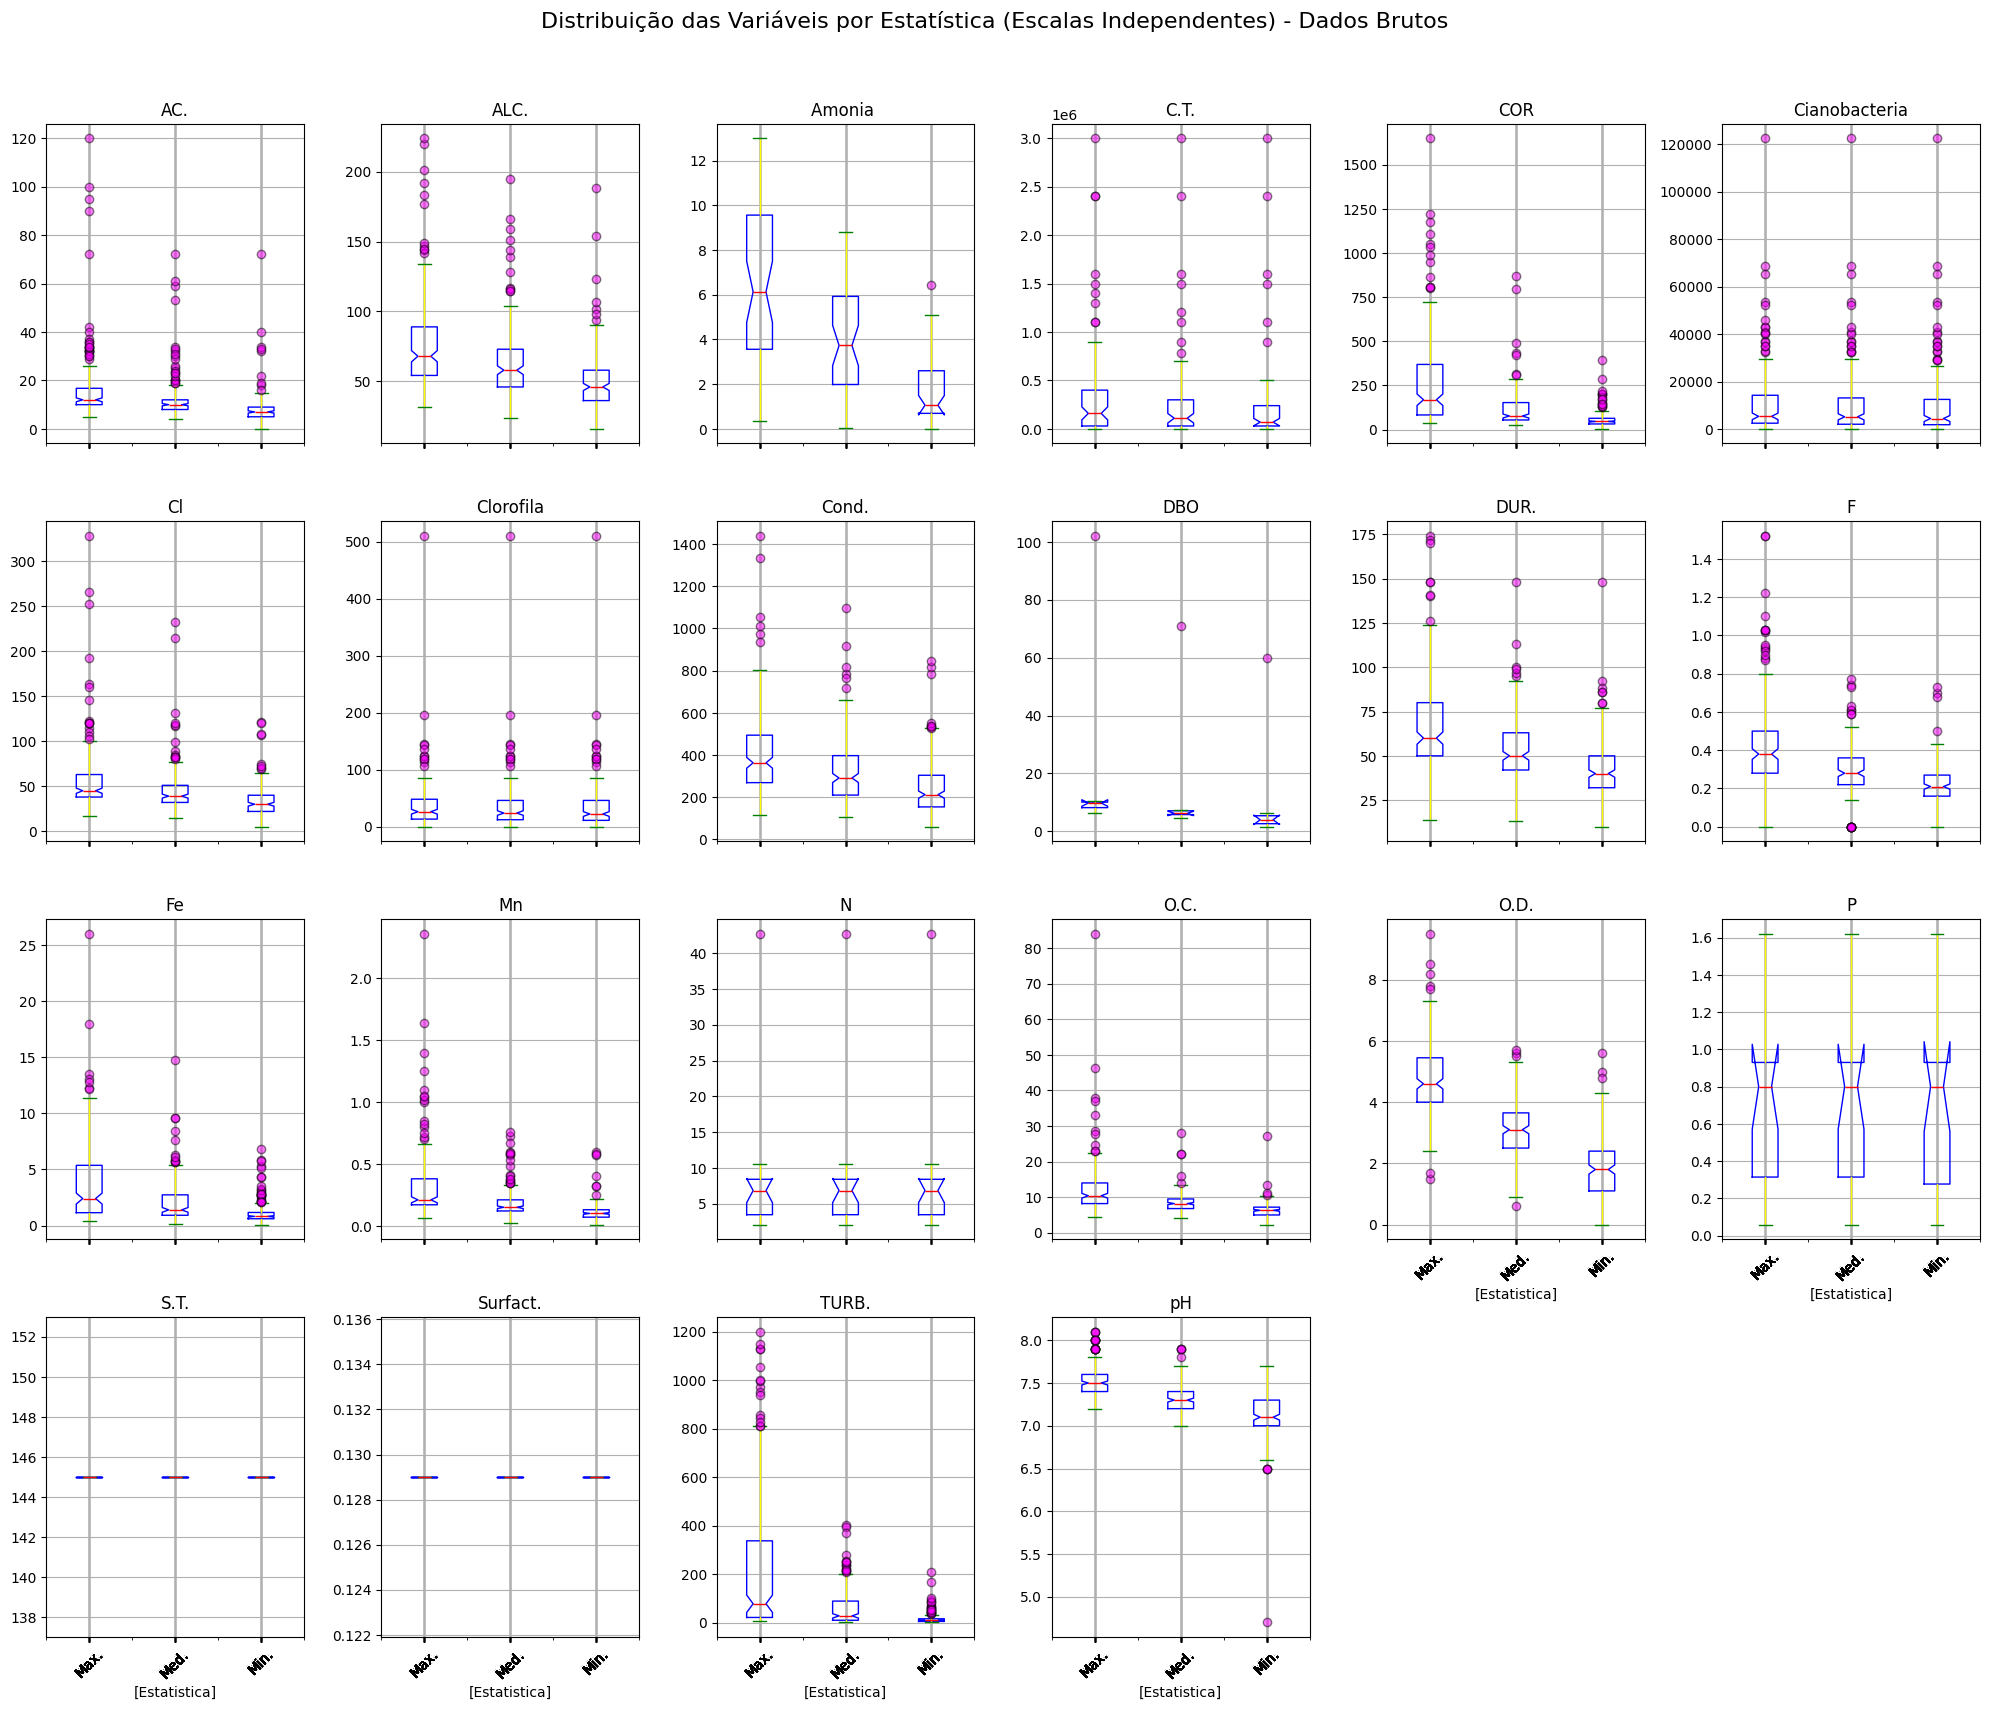

In [ ]:
# Formatação dos boxplots

## Guarda as cores para cada parte do boxplot num dicionário
cores_customizadas = {      
    'boxes': 'Blue',
    'medians': 'Red',
    'whiskers': 'Yellow',
    'caps': 'Green'
}

estilo_outliers = dict(             # Determina a formatação dos pontos outliers
    markerfacecolor = 'magenta',    # Determina a cor dos pontos      
    marker = 'o',                   # Determina o formato dos pontos (no caso, círculos perfeitos)
    alpha = 0.5                     # Determina a opacidade / transparência dos pontos
)

In [ ]:
def boxplot_tudo(df):
    """
    Gera boxplots para todas as variáveis numa única figura.

    df: Seleciona o dataframe em que se deseja.
    """
    if 'Estatistica' in df.columns:
        df.boxplot(by='Estatistica',        # Agrupa os dados por Estatística
            layout=(5, 6),                  # Organiza os boxplots em linhas e colunas
            figsize=(20,20),                # Determina o tamanho da figura
            sharey = False,                 # Faz com que diferentes variáveis apresentem diferentes escalas (mais apropriadas para cada uma)
            rot = 45,                       # Rotaciona os rótulos para evitar sobreposição
            color = cores_customizadas,     # Aplica as cores escolhidas
            flierprops = estilo_outliers,
            notch = True,
            )   
        # Aplica a formatação dos outliers escolhida
        plt.suptitle('Distribuição das Variáveis por Estatística (Escalas Independentes)', fontsize=16, y=1.02)

        # Ajusta o espaçamento entre os gráficos para não ficarem grudados
        plt.tight_layout()

        # Salva a figura
        salvar_plot('boxplot_tudo')
    else:
        print('Esse dataframe não apresenta coluna \'Estatistica\'. Talvez você tenha usado um dataframe pivotado?')

In [ ]:
def boxplot_estatisticas(df):
    """
    Cria boxplots separados para cada estatística (Min, Med, MAx)
    """

    # Criando variaveis contendo cada tipo de estatistica (Min, Med, Max)

    cols_min = [coluna for coluna in df.columns if coluna.endswith('Min.')] 

    cols_med = [coluna for coluna in df.columns if coluna.endswith('Med.')] 

    cols_max = [coluna for coluna in df.columns if coluna.endswith('Max.')]

    if not cols_max and cols_med and cols_min:
        print("Não foram encontradas colunas finalizando com Min., Med. ou Max."
        "Talvez o DataFrames selecionado não esteja pivotado.")
        pass
    
    # Seleciona colunas com a estatística "Min."
    if not cols_min:
        print("Não foram encontradas colunas *_Min. no DataFrame")
        pass

    else:
        ax_min = df[cols_min].plot(kind='box',
                                    subplots=True,
                                    layout=(6,8),
                                    figsize=(20,20),
                                    sharey=False,
                                    color = cores_customizadas,
                                    flierprops = estilo_outliers
                                    )
        plt.suptitle('Distribuição dos valores mínimos de cada variável (Escalas independentes)', fontsize = 16, y = 1.02)

        plt.tight_layout()
        
        salvar_plot("boxplots_min")

    # Seleciona colunas com a estatística "Med."
    if not cols_med:
        print("Não foram encontradas colunas *_Med. no DataFrame")
        pass
    else:
        ax_med = df[cols_med].plot(kind='box',
                                    subplots=True,
                                    layout=(6,8),
                                    figsize=(20,20),
                                    sharey=False,
                                    color = cores_customizadas,
                                    flierprops = estilo_outliers
                                    )
        plt.suptitle('Distribuição dos valores médios de cada variável (Escalas independentes)', fontsize = 16, y = 1.02)

        plt.tight_layout()

        salvar_plot("boxplots_med")

    # Seleciona colunas com a estatística "Max."
    if not cols_max:
        print("Não foram encontradas colunas *_Max. no DataFrame")
        pass
    else:
        ax_max = df[cols_max].plot(kind='box',
                                    subplots=True,
                                    layout=(6,8),
                                    figsize=(20,20),
                                    sharey=False,
                                    color = cores_customizadas,
                                    flierprops = estilo_outliers
                                    )
        plt.suptitle('Distribuição dos valores máximos de cada variável (Escalas independentes)', fontsize = 16, y = 1.02)

        plt.tight_layout()

        salvar_plot("boxplots_max")

# Dados Faltantes

In [ ]:
# Seção biblioteca missingno
def visualizacoes_missingno(df):
    """
    Gera visualizações dos dados faltantes no DataFrame de interesse com os métodos da biblioteca missingno.

    df: Seleciona o DataFrame de interesse.
    """
    ## Gera uma matriz representando dados faltantes/coluna
    msno.matrix(df,) 
    salvar_plot("matrix_msno")

    ## Gera um gráfico de barras
    msno.bar(df) 
    salvar_plot('bar_msno')

    ## Gera um mapa de calor
    msno.heatmap(df) 
    salvar_plot('heatmap_msno')

    ## Gera um dendograma
    msno.dendrogram(df)  
    salvar_plot('dendogram_msno')   

In [ ]:
# Taxa de faltantes / ano (0 → completo, 1 → tudo faltando)
def faltantes_ano(df, plot=False):
   """
   Gera um heatmap de dados faltantes ao longo dos anos.

   df: DataFrame de interesse.
   """
   # Separa colunas de data numa lista
   colunas_data = [coluna for coluna in df.columns if str(df[coluna].dtype).startswith('datetime')]

   missing_por_ano = (df.drop(columns=colunas_data).groupby(df["Data"].dt.year).apply(lambda x: x.isna().mean()*100))

   ## transpor para variáveis ficarem no eixo vertical
   missing_por_ano = missing_por_ano.T 

   plt.figure(figsize=(18, 10))
   sns.heatmap(
      missing_por_ano,
      cmap="RdBu_r",  # azul = completo | vermelho = faltante
      vmin=0,
      vmax=100,
      linewidths=0.5,
      linecolor="black"
   )

   plt.title("Taxa de dados faltantes (%) por variável e ano")
   plt.xlabel("Ano")
   plt.ylabel("Variável")

   salvar_plot("faltantes_ano")

   if plot:
      plt.show()

In [ ]:
# Taxa de faltantes / mês

def faltantes_mes(df, plot=False):
    """
    Gera um heatmap de dados faltantes em função dos meses.

    df: DataFrame de interesse.
    """
    # Separa colunas de data numa lista
    colunas_data = [coluna for coluna in df.columns if str(df[coluna].dtype).startswith('datetime')]

    missing_meses = (df.drop(columns=colunas_data)).groupby(df['Data'].dt.year).apply(lambda x: x.isna().sum())

    missing_meses = missing_meses.T

    plt.figure(figsize=(18, 10))
    sns.heatmap(
        missing_meses,
        cmap="RdBu_r",
        vmin=0,
        vmax=12,
        linewidths=0.5,
        linecolor="black",
        cbar_kws={"label": "Meses faltantes"}
    )

    plt.title("Meses faltantes por variável e ano")
    plt.xlabel("Ano")
    plt.ylabel("Variável")

    salvar_plot('faltantes_mes')

    if plot:
        plt.show()

# Scatter Plots

<Axes: xlabel='data_normalizada', ylabel='pH'>

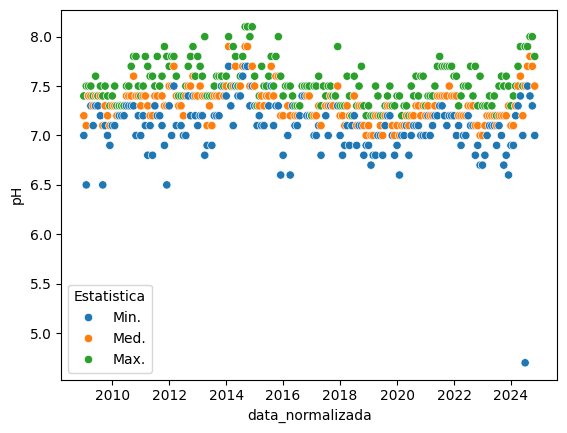

In [5]:
dados_brutos, metadados, variaveis = dados(r"data\in\dados_brutos.xlsx")
dados_limpos, metadados, variaveis = dados(r"data\in\dados_limpos.xlsx")

sns.scatterplot(data=dados_limpos, x='data_normalizada', y='pH', hue='Estatistica')

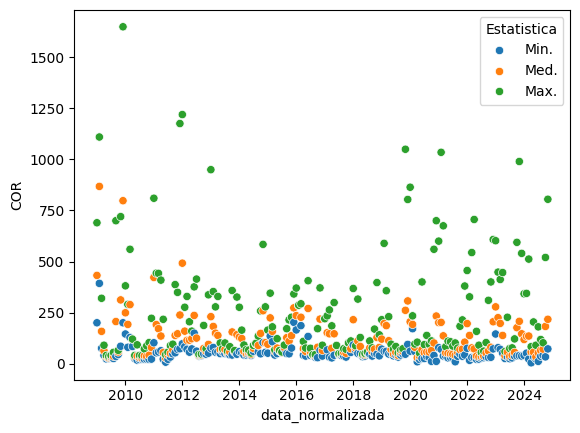

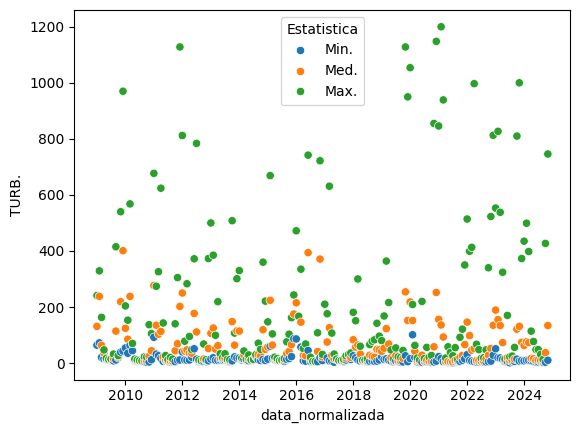

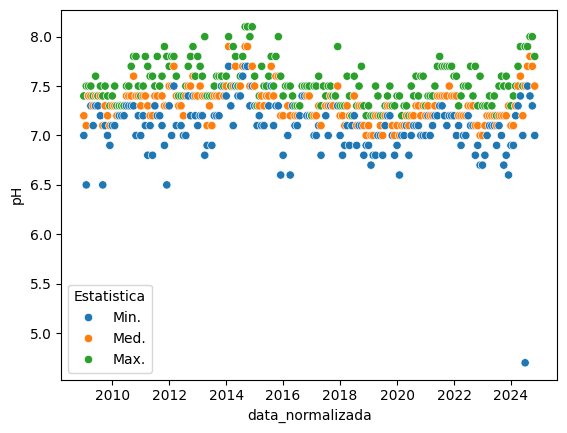

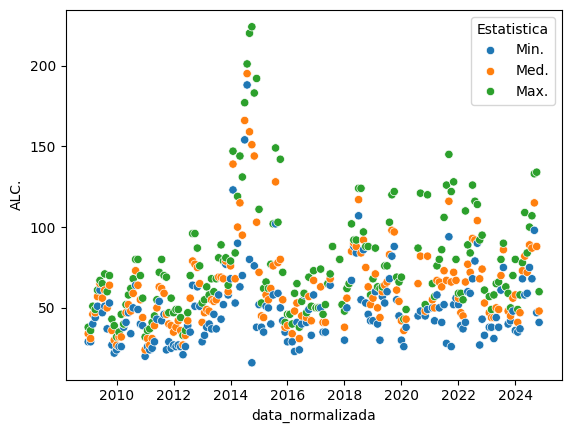

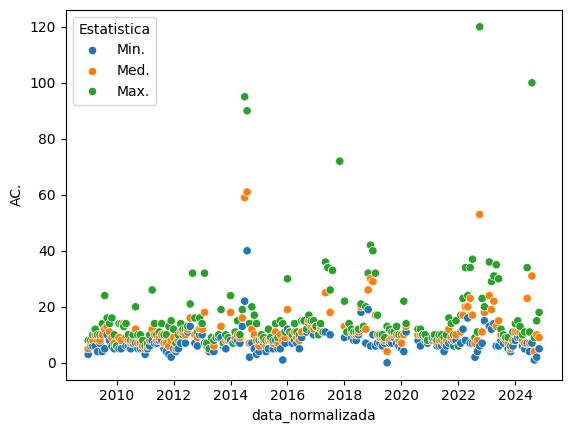

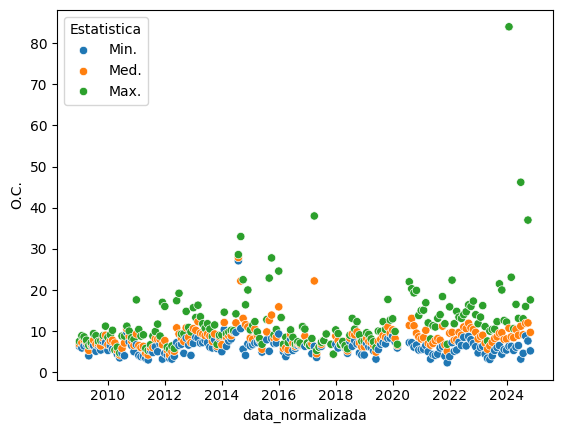

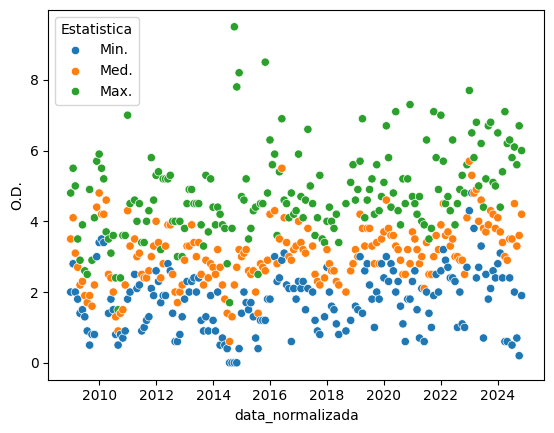

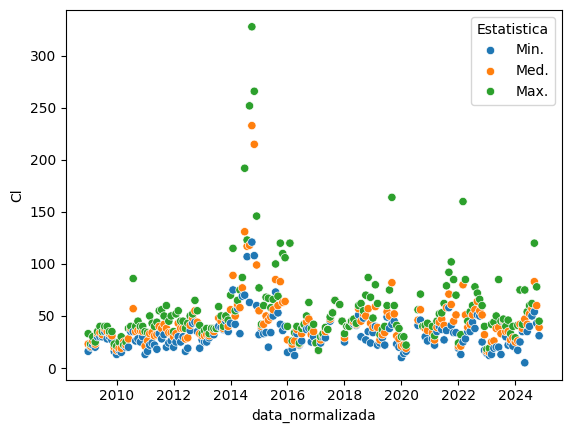

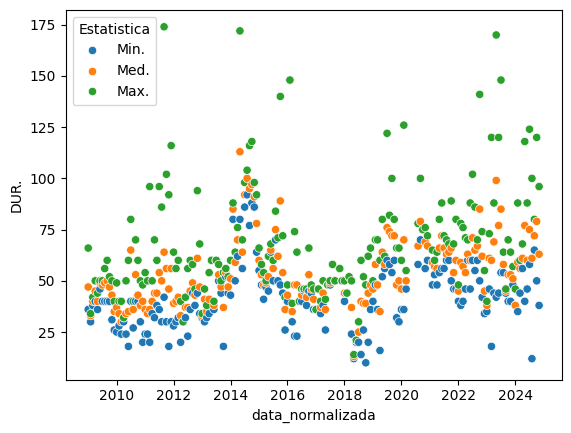

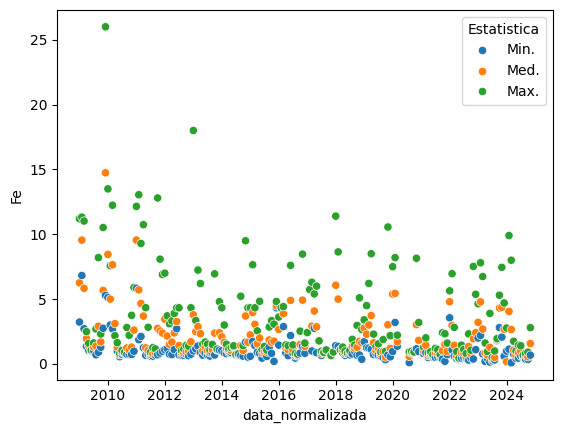

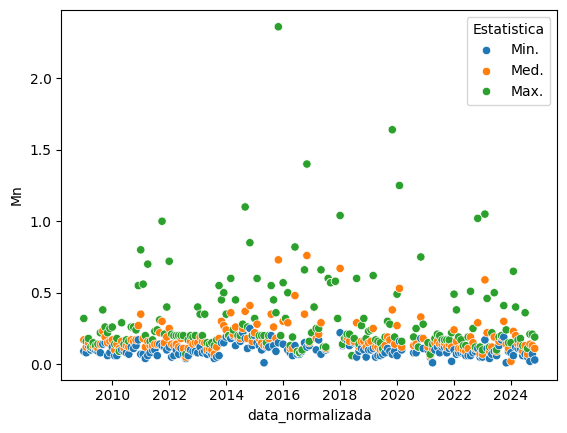

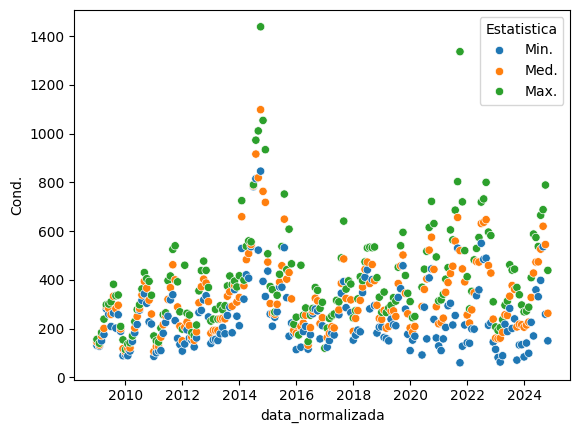

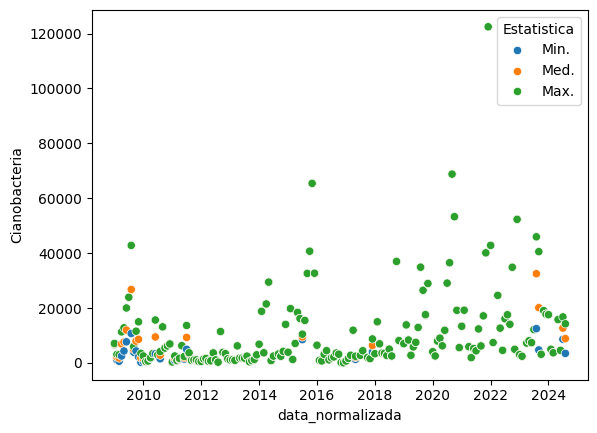

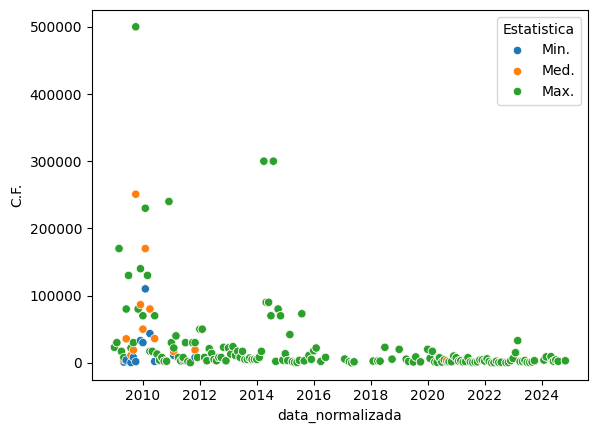

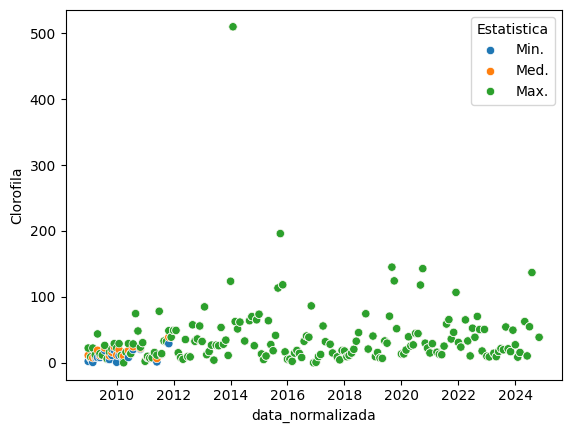

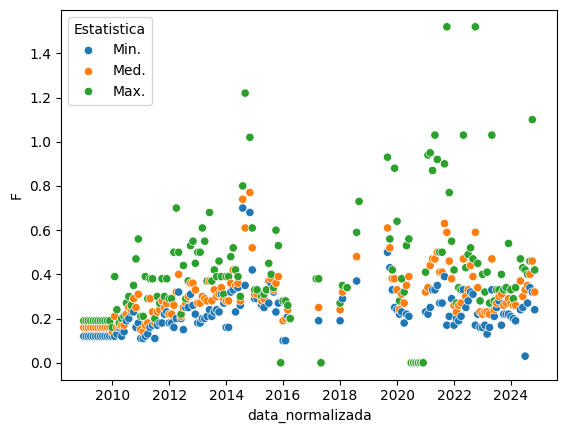

In [14]:
for col in variaveis:
    sns.scatterplot(data=dados_limpos,
                    x='data_normalizada',
                    y = col, 
                    hue='Estatistica', 
                    # legend=False,
                    
                    )
    plt.show()



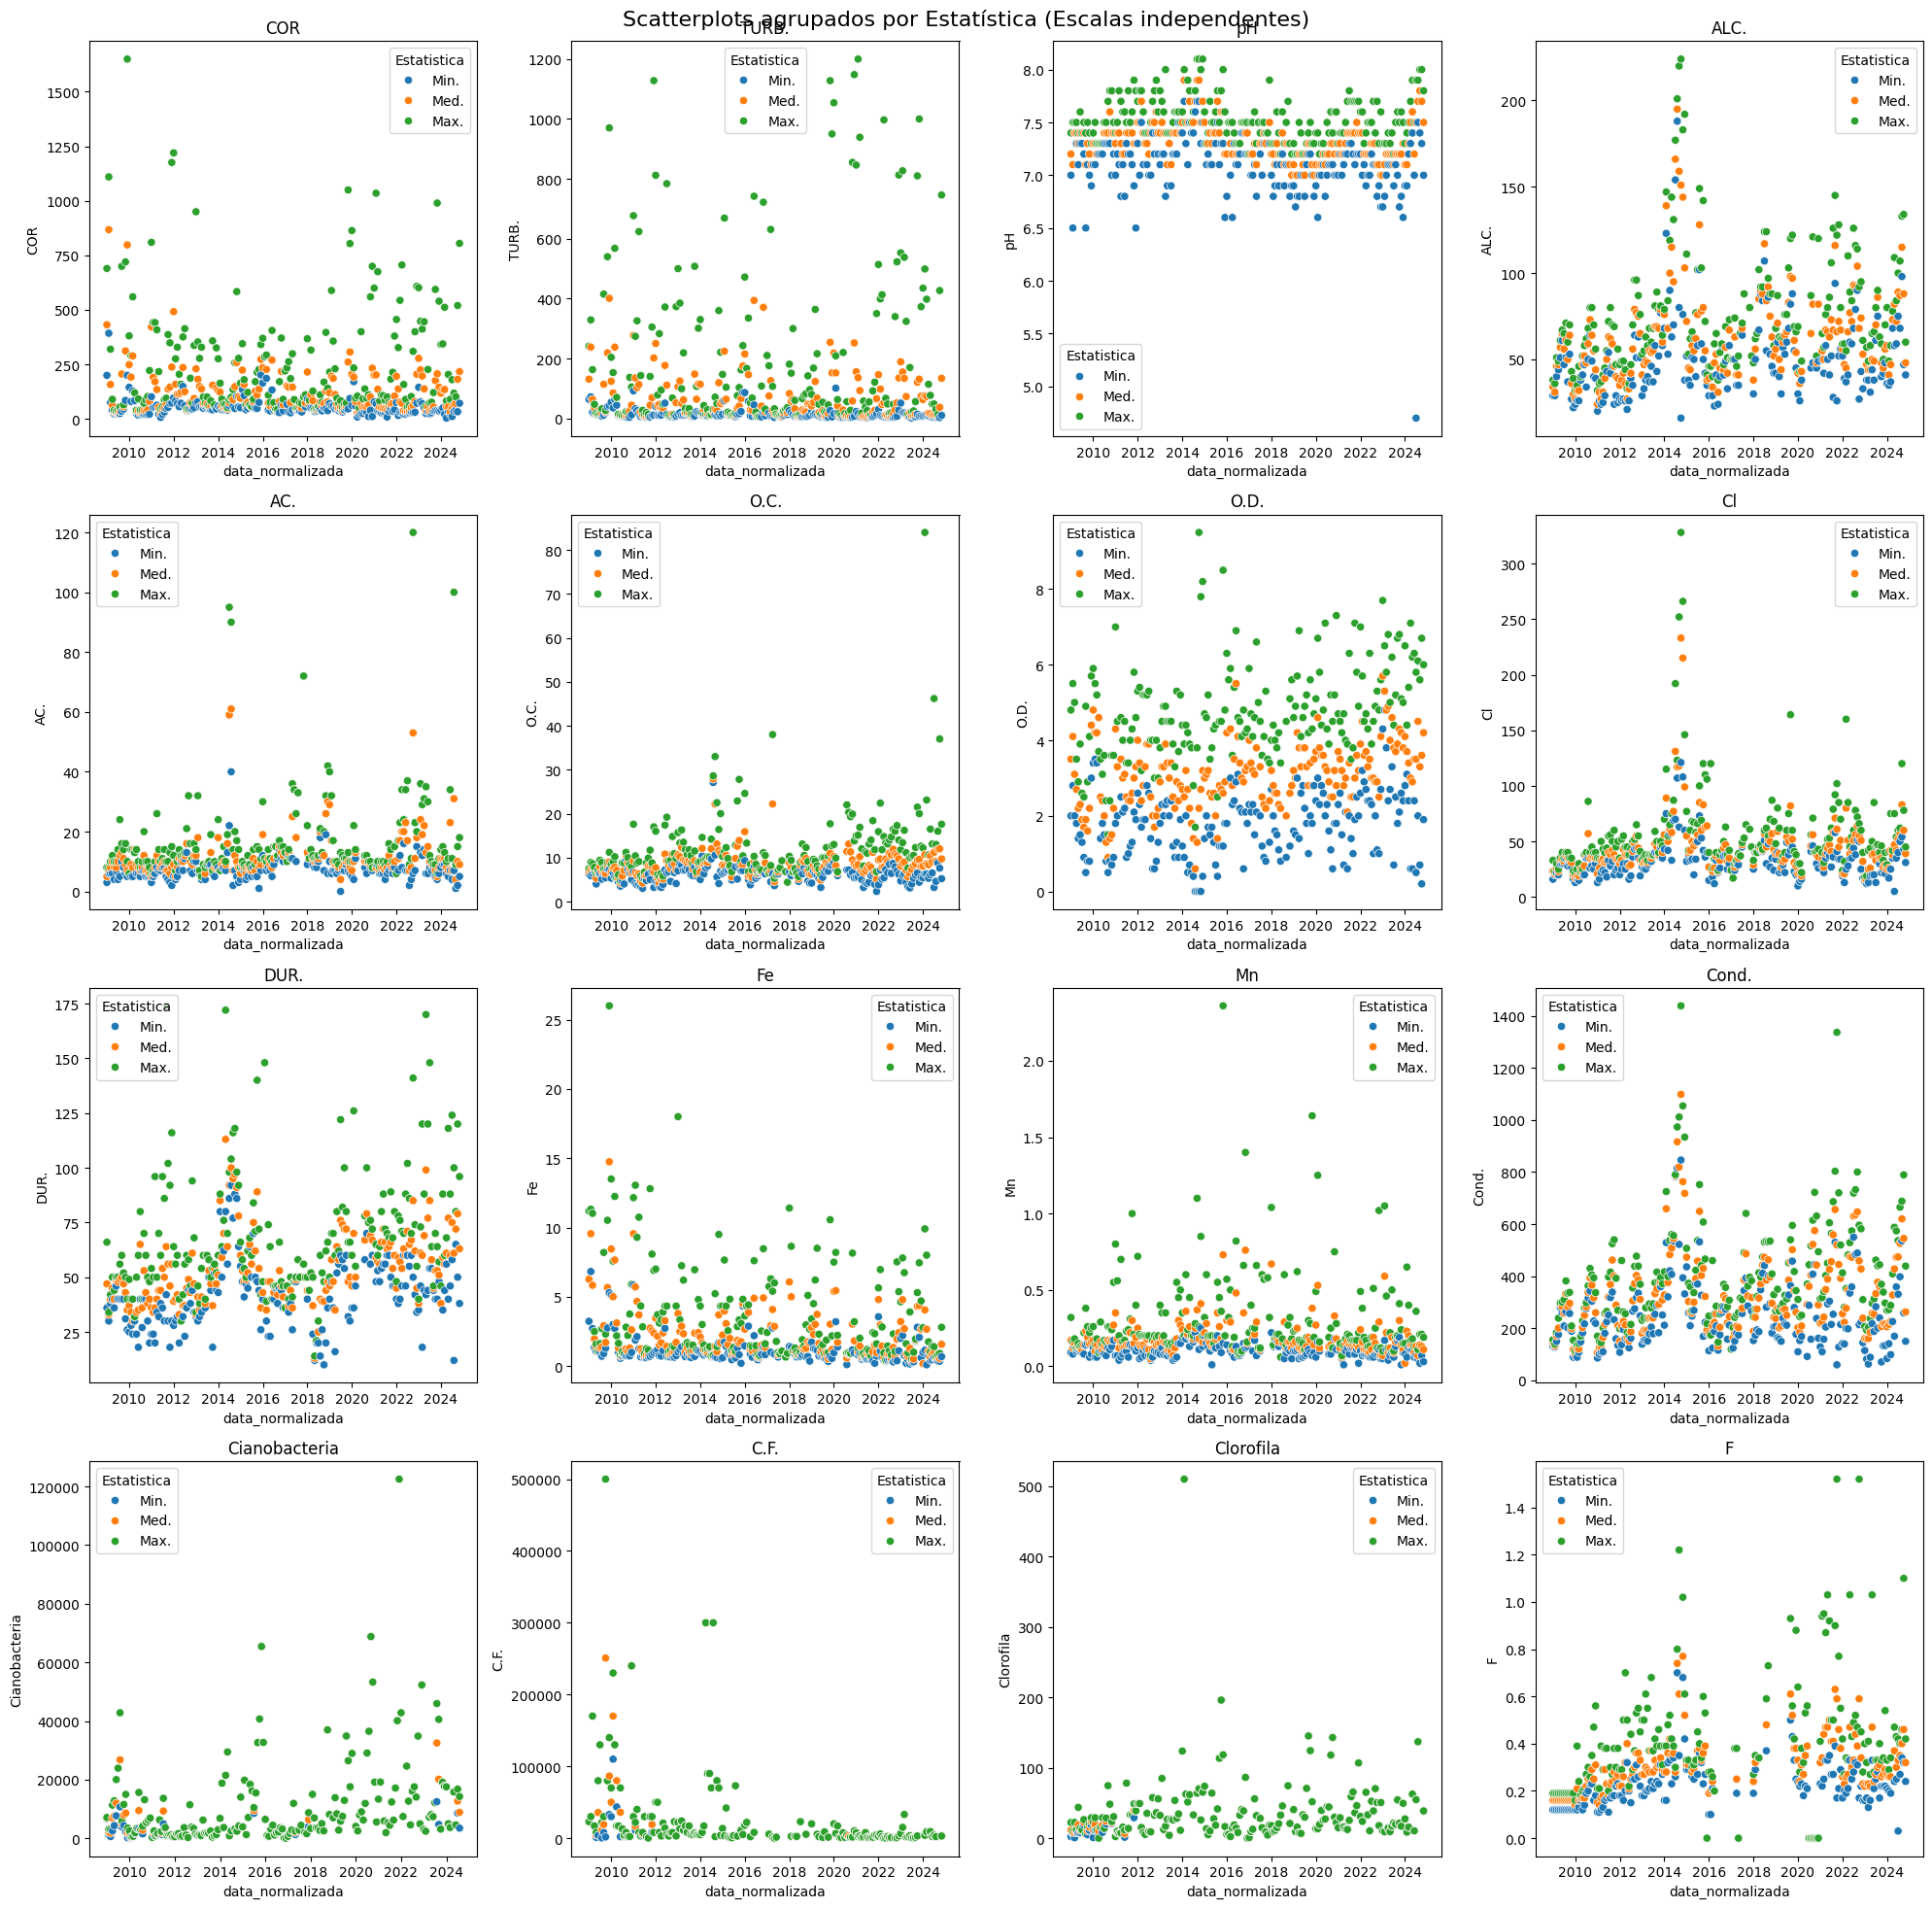

In [42]:
fig, axes = plt.subplots(nrows=math.ceil(len(variaveis) / 4), ncols=4,
                            figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(variaveis):
    sns.scatterplot(
        data=dados_limpos,
        x='data_normalizada',
        y=col,
        hue='Estatistica',
        ax=axes[i]
    )

    axes[i].set_title(f'{col}')
plt.suptitle('Scatterplots agrupados por Estatística (Escalas independentes)', fontsize=16)
plt.tight_layout()
plt.show()

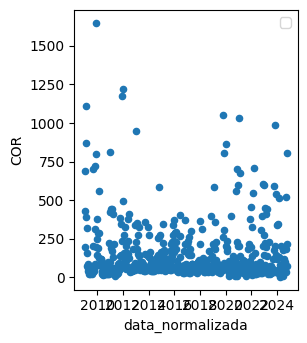

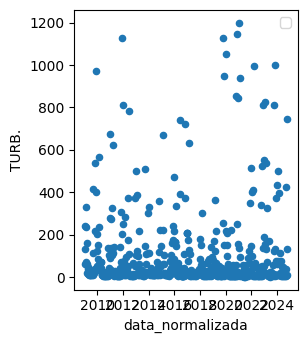

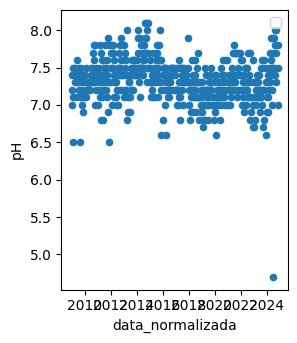

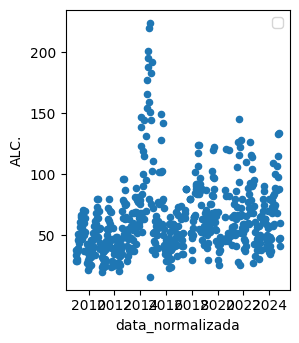

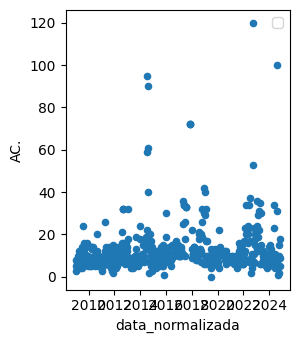

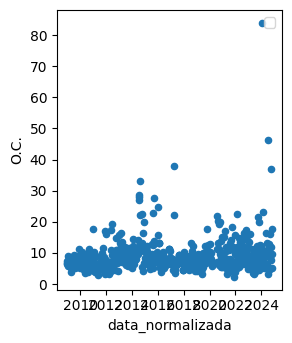

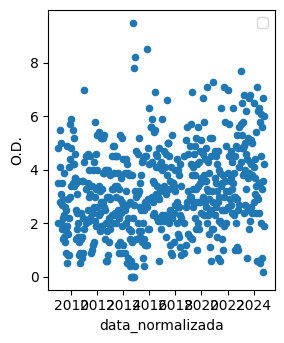

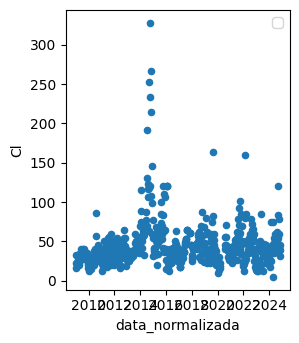

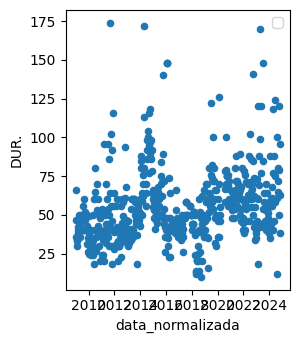

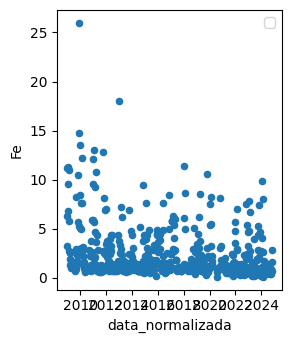

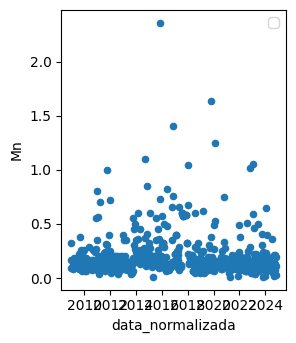

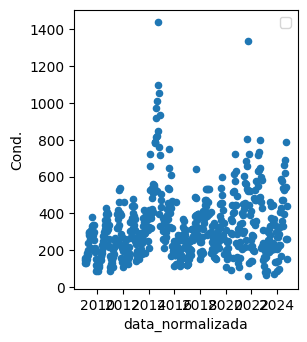

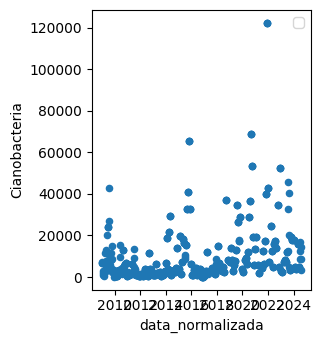

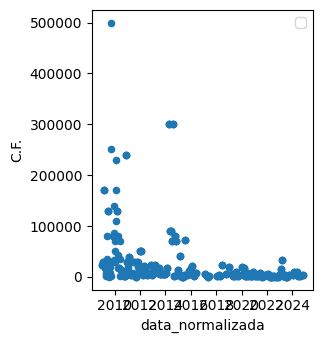

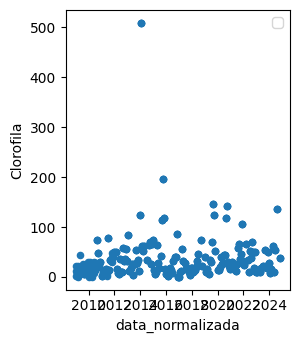

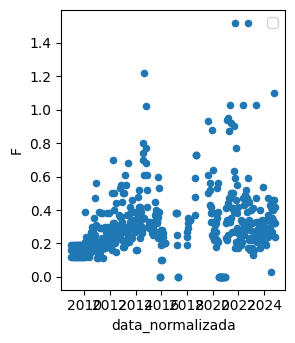

In [31]:
for col in variaveis:
    ax = dados_limpos.plot(kind='scatter',
                           subplots=True,
                           layout=(6, 8),
                           figsize=(20, 20),
                           x='data_normalizada',
                           y=col,
                           sharey=False,
                           )
    
    plt.tight_layout()
    plt.show()

In [ ]:
def scatter_tudo(df):
    fig, axes = plt.subplots(nrows=len(variaveis)//2, ncols=len(variaveis//2),
                             figsize=(10, 5 * len(variaveis)))
    for i, col in enumerate(variaveis):
        sns.scatterplot(
            data=df,
            x='data_normalizada',
            y=col
            hue='Estatistica',
            ax=axes[i]
        )

        axes[i].set_title(f'{col}')
    plt.suptitle('Scatterplots agrupados por Estatística')
    plt.tight_layout()
    plt.show()

# Correlação

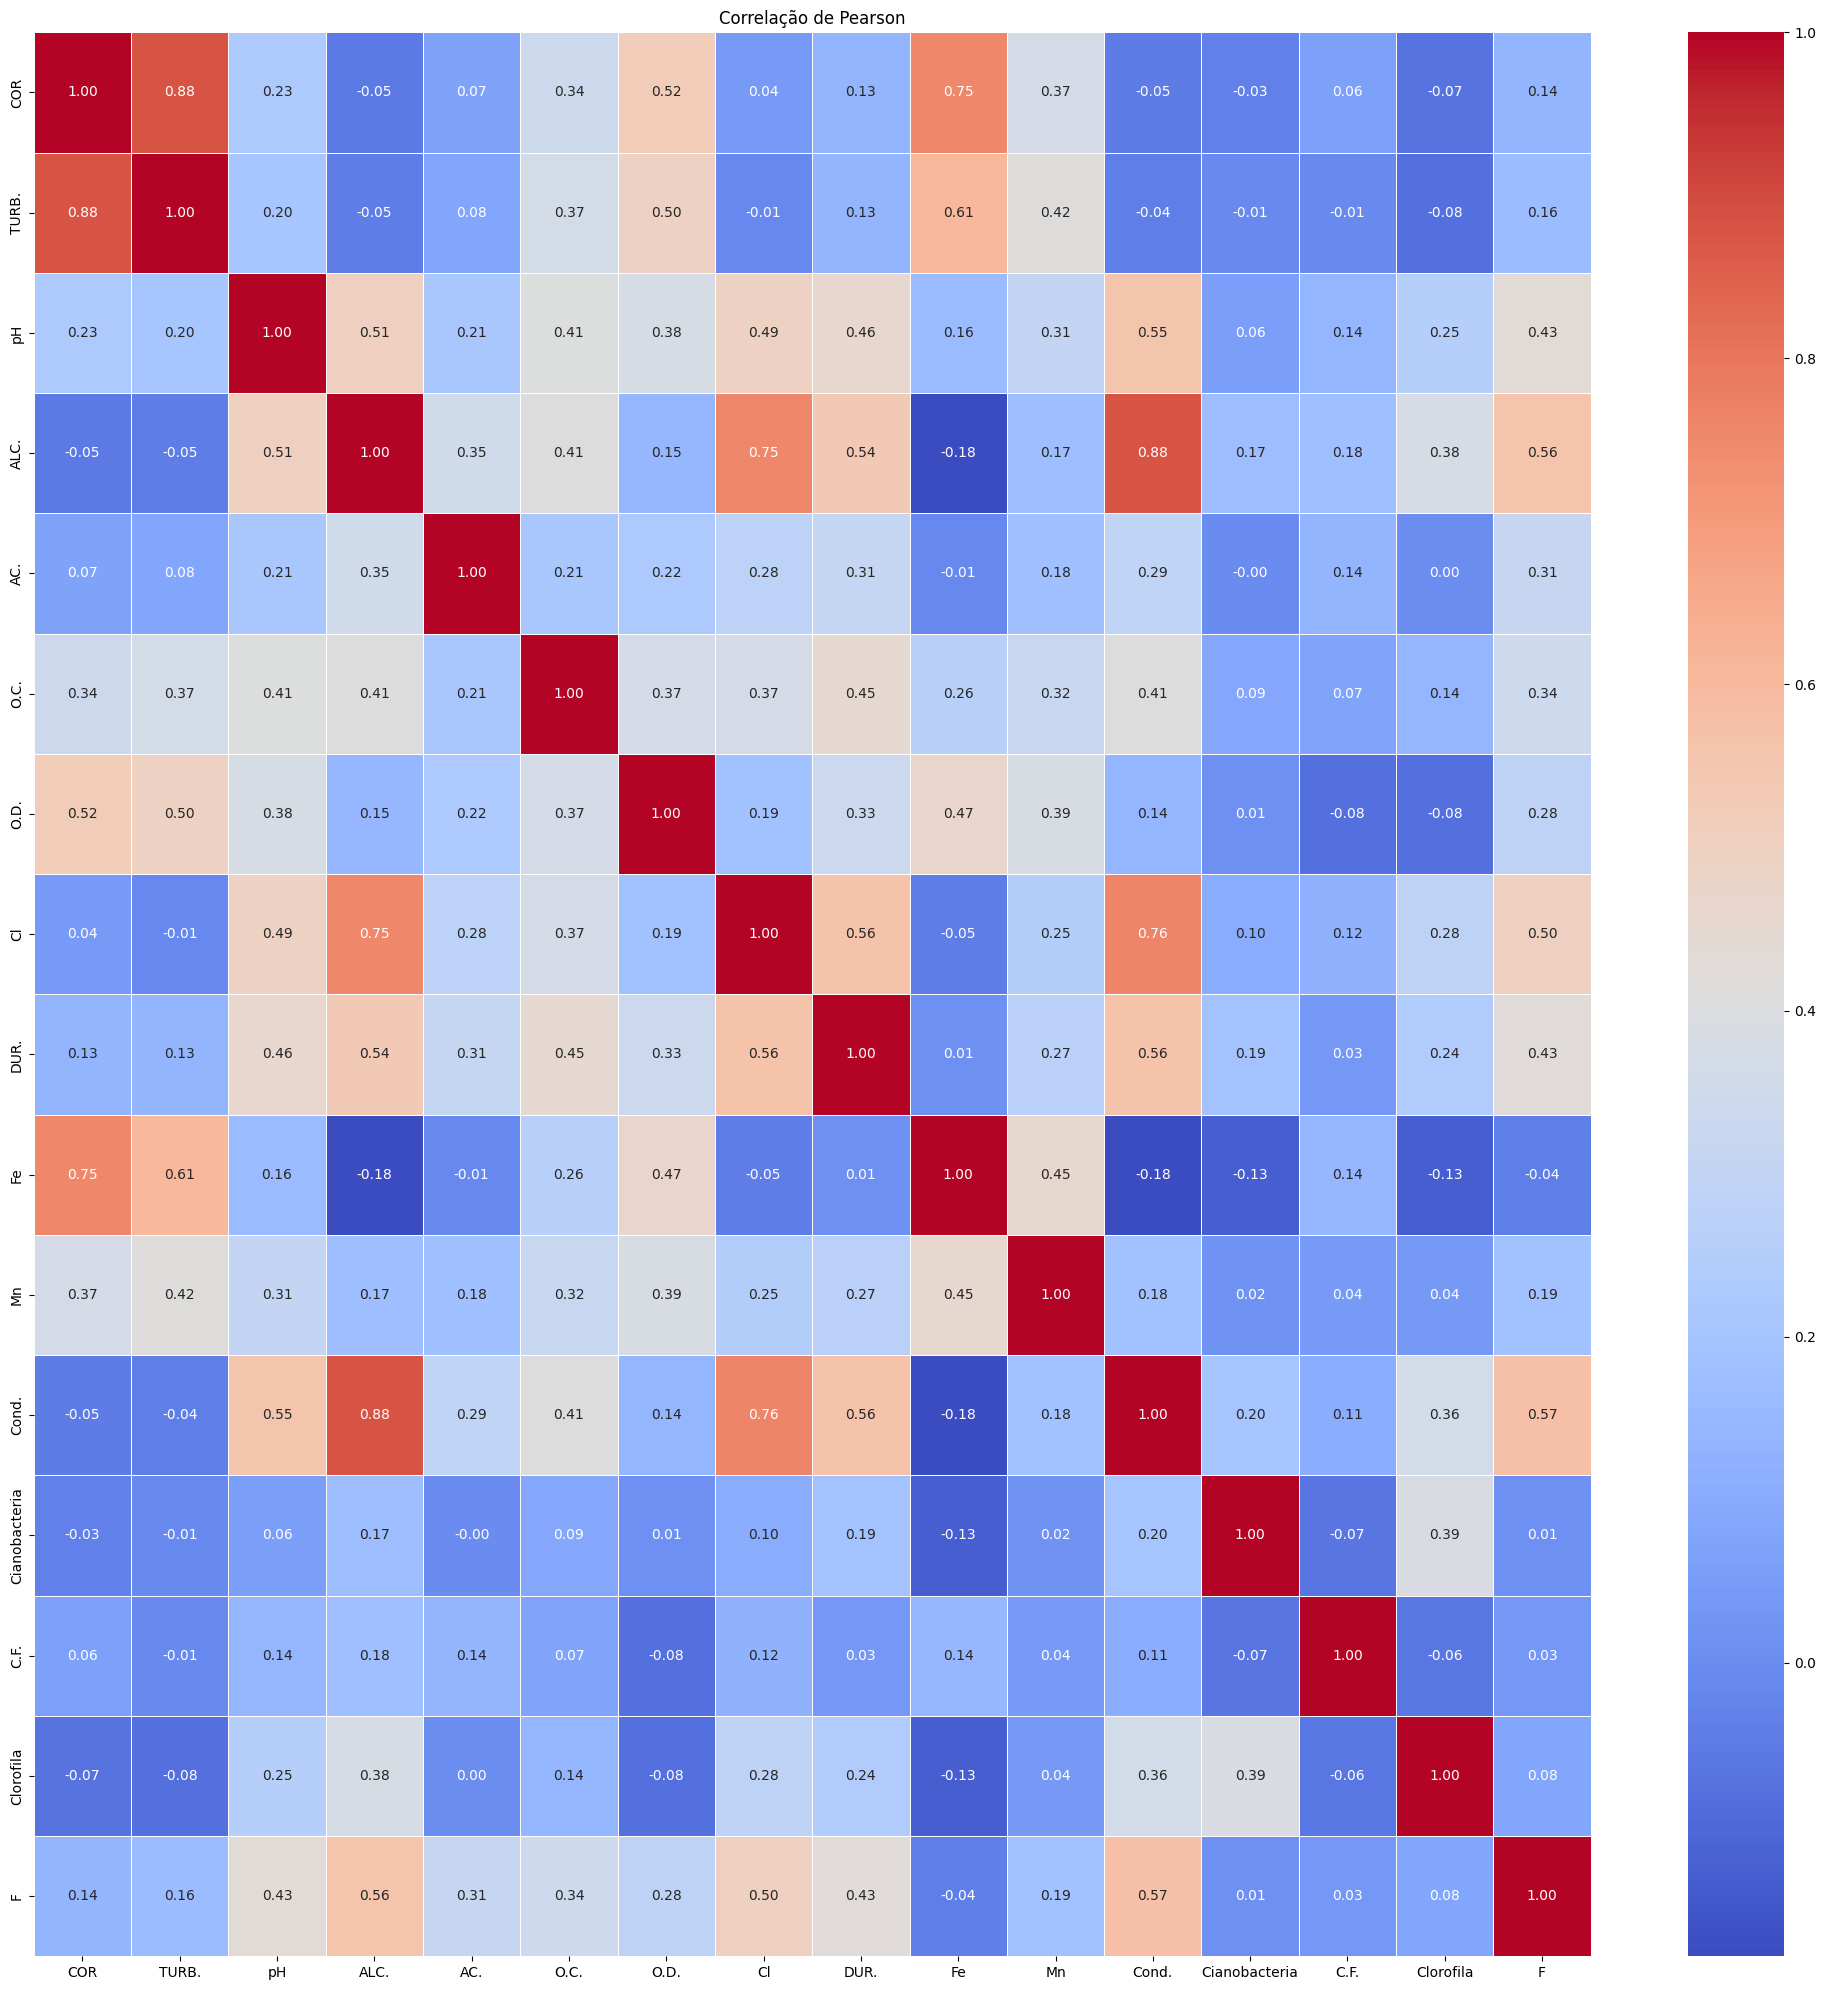

In [48]:
corr_pearson = dados_limpos[variaveis].corr(method='pearson')

plt.figure(figsize=(20,20))

sns.heatmap(data=corr_pearson, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            )

plt.title('Correlação de Pearson')
plt.tight_layout()

In [50]:
def correlacao(df, method='pearson'):

    matriz = df[variaveis].corr(method=method)

    plt.figure(figsize=(20,20))

    sns.heatmap(data=matriz, 
                annot=True, 
                cmap='coolwarm', 
                fmt=".2f", 
                linewidths=0.5,
                )

    plt.title('Correlação de Pearson')
    plt.tight_layout()

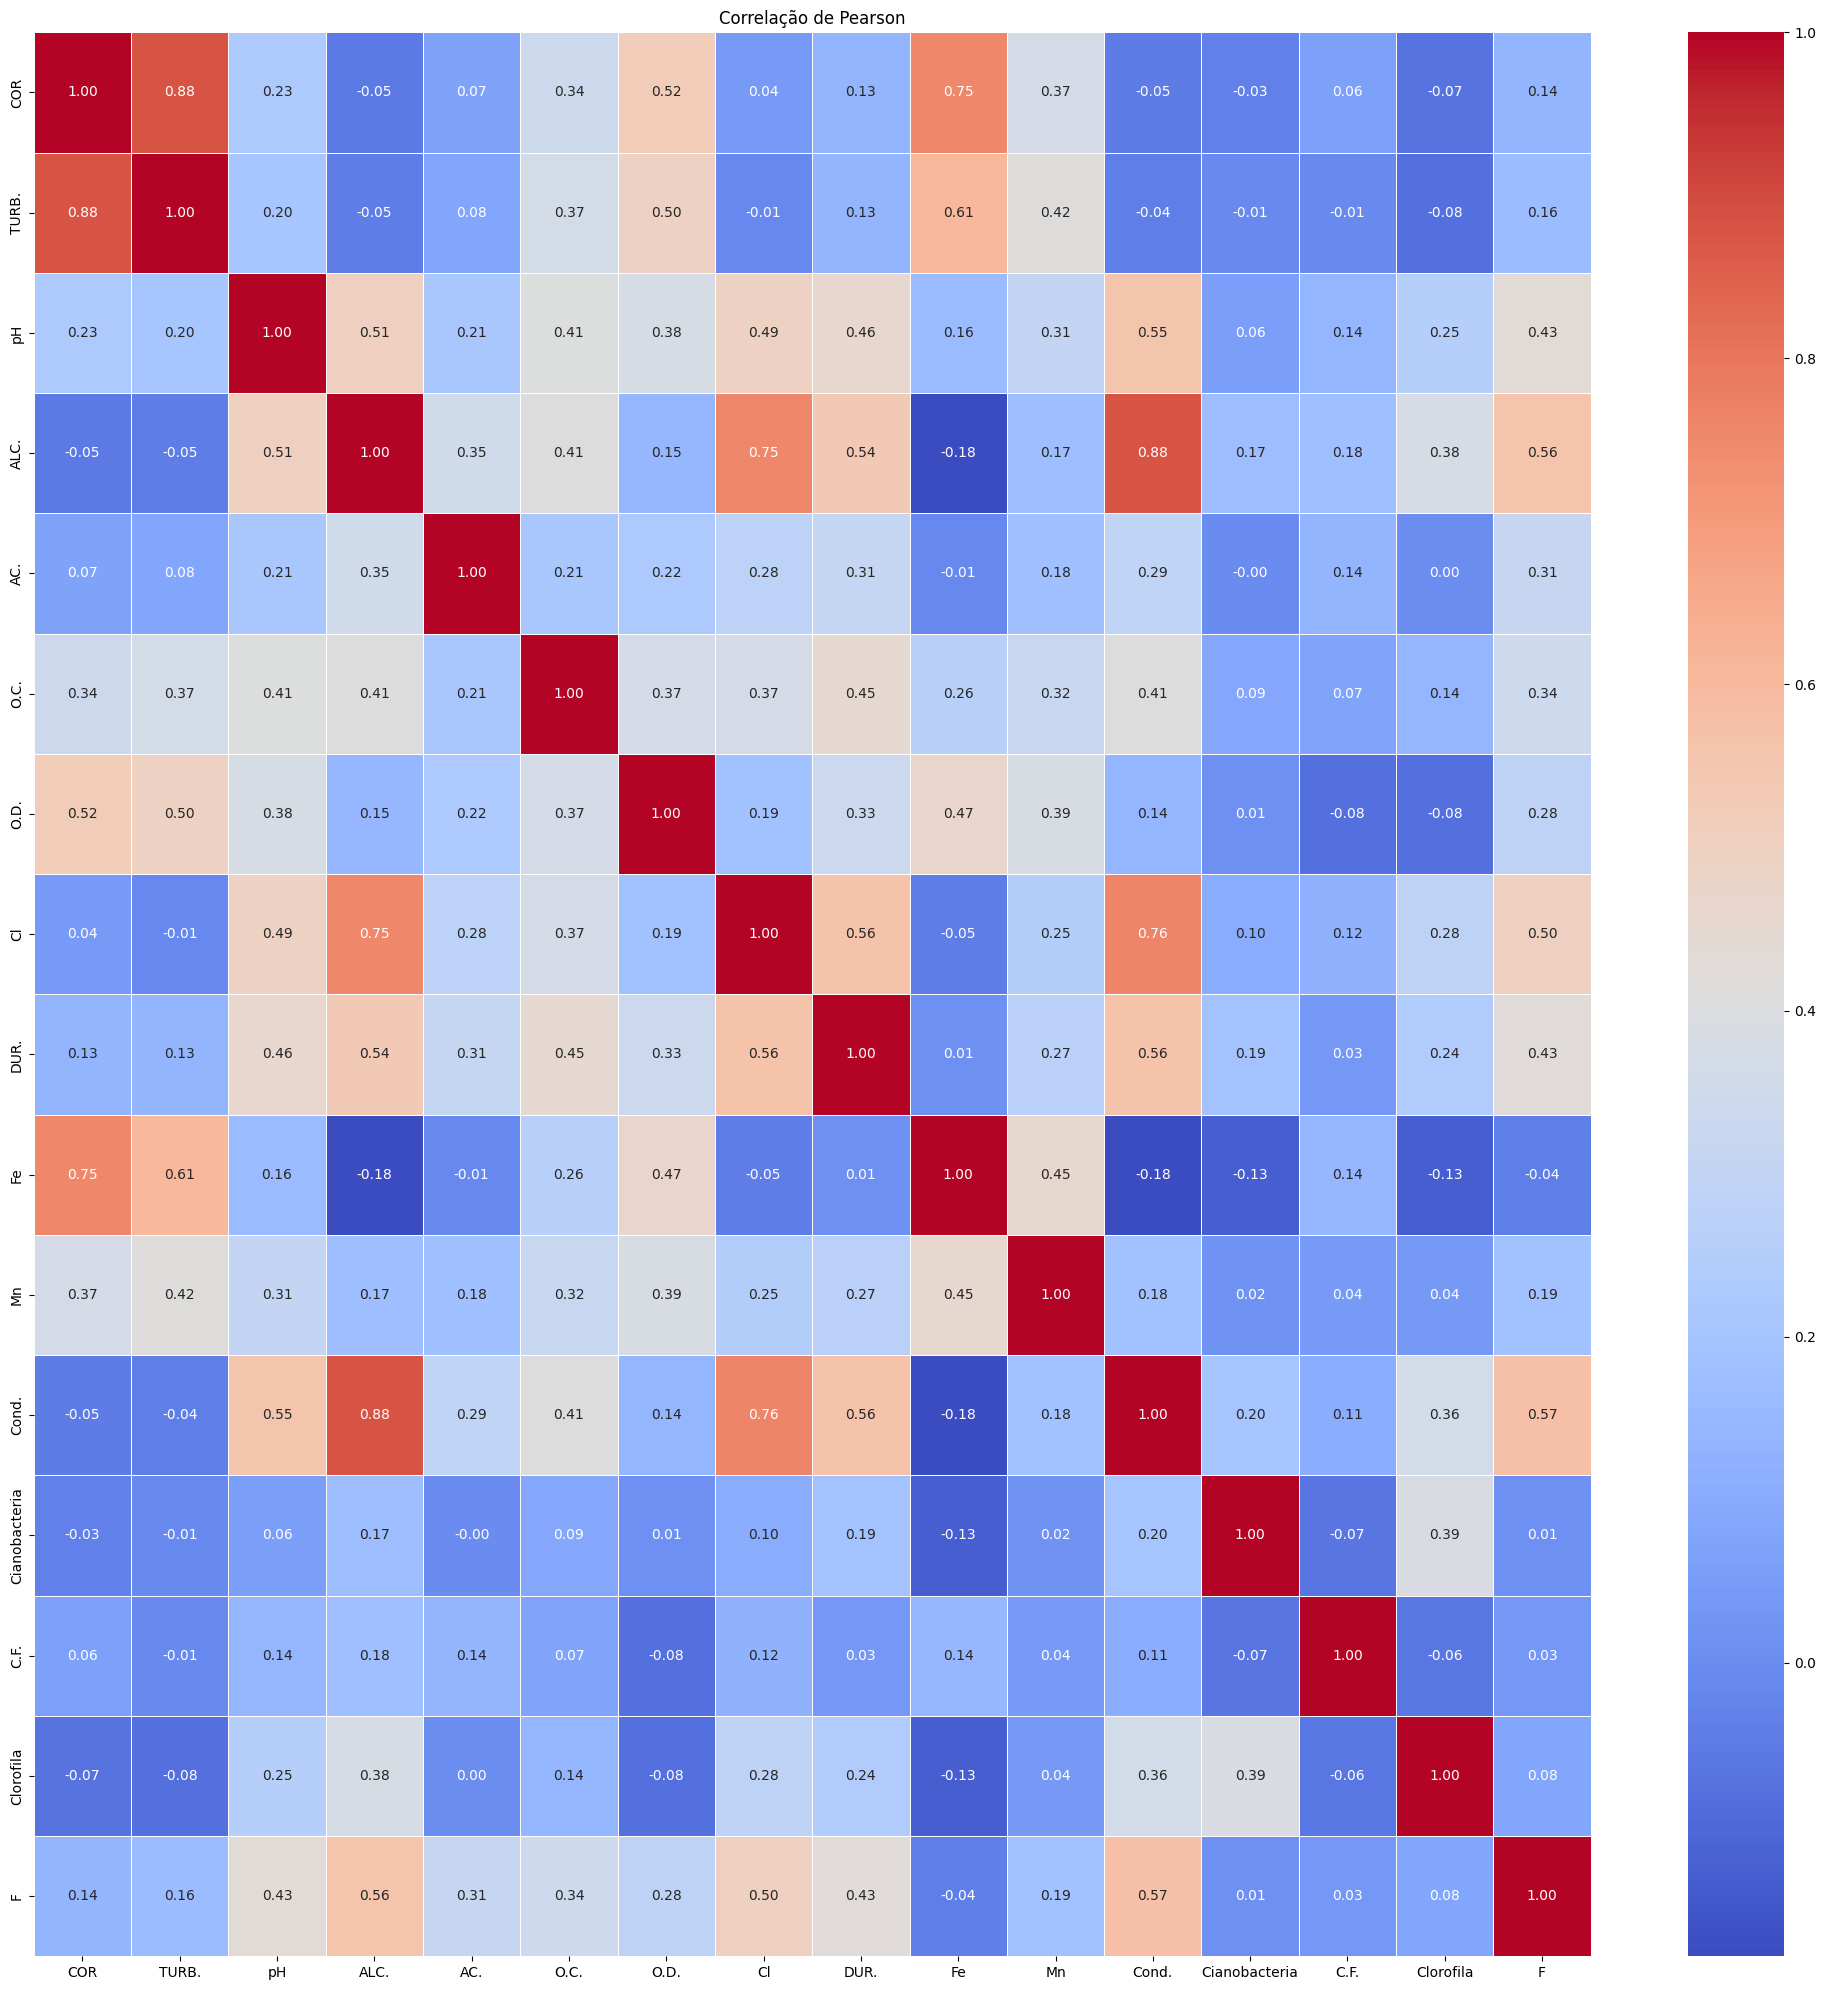

In [51]:
correlacao(dados_limpos)

In [ ]:
# Todas as visualizações

def visualizacoes_todas(df):    # Gera todas as visualizações, exceto os boxplots de estatísticas
    visualizacoes_missingno(df)
    faltantes_ano(df)
    faltantes_mes(df)
    boxplot_tudo(df)